<a href="https://colab.research.google.com/github/Saphirarya/AI-Lab-4/blob/main/CMP7239_Lab4_Decision_Tree_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Machine Learning COM7018***

## Decision Tree

## Dr. Mohamed Ihmeida

## Introduction to Decision Tree

***TASK***

* Ensure that you run and comprehend the code. The Decision Tree operates on the Iris dataset, which we previously discussed.
* You must save a copy of the code on GitHub, make it public, and share your link when submitting your Session 4 work.
* This practice is beneficial for submitting your code for CW1.
* Can you use decision tree for your own dataset (challenge)

**Decision trees** are a popular and powerful tool used in various fields such as `machine learning`, data mining, and statistics.


They provide a clear and intuitive way to make decisions based on data by modeling the relationships between different variables.


This session focus on what decision trees are, how they work, their advantages and disadvantages, and their applications

What is a Decision Tree?

* A decision tree in machine learning is a versatile, interpretable algorithm used for predictive modelling.

* It structures decisions based on input data, making it suitable for both `classification` and `regression` tasks

*  A decision tree is a `flowchart-like structure` used to make decisions or predictions.

*  It consists of nodes representing decisions or tests on attributes, branches representing the outcome of these decisions, and leaf nodes representing final outcomes or predictions.


* Each internal node corresponds to a test on an attribute, each branch corresponds to the result of the test, and each leaf node corresponds to a class label or a continuous value.

**Structure of a Decision Tree**

1. **Root Node**: Represents the entire dataset and the initial decision to be made.

2. **Internal Nodes**: Represent decisions or tests on attributes. Each internal node has one or more branches.

3. **Branches**: Represent the outcome of a decision or test, leading to another node.

4. **Leaf Nodes**: Represent the final decision or prediction. No further splits occur at these nodes.

![DT-structure](https://www.statlect.com/images/decision-tree-structure.png)

# Advantages of Decision Trees

1.**Simplicity and Interpretability**: Decision trees are easy to understand and interpret. The visual representation closely mirrors human decision-making processes.

2.**Versatility**: Can be used for both classification and regression tasks.

3.**No Need for Feature Scaling**: Decision trees do not require normalization or scaling of the data.

4.**Handles Non-linear Relationships**: Capable of capturing non-linear relationships between features and target variables.

# Disadvantages of Decision Trees

1.**Overfitting**: Decision trees can easily overfit the training data, especially if they are deep with many nodes.

2.**Instability**: Small variations in the data can result in a completely different tree being generated.

3.**Bias towards Features with More Levels**: Features with more levels can dominate the tree structure.

**Applications of Decision Trees**

* *`Business Decision Making`*: Used in strategic planning and resource allocation.

* *`Healthcare`*: Assists in diagnosing diseases and suggesting treatment plans.

* *`Finance`*: Helps in credit scoring and risk assessment.

* *`Marketing`*: Used to segment customers and predict customer behavior

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load the dataset
uploaded = files.upload()
df = pd.read_csv('IoT_Intrusion.csv')

print('Dataset loaded:')
print(df.shape)
print(df.columns.tolist())


Saving IoT_Intrusion.csv to IoT_Intrusion.csv
Dataset loaded:
(1048575, 47)
['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label']


In [2]:
# Group 33 attack types into 8 categories
category_map = {
    # DDoS family
    'DDoS-ICMP_Flood': 'DDoS', 'DDoS-UDP_Flood': 'DDoS', 'DDoS-TCP_Flood': 'DDoS',
    'DDoS-PSHACK_Flood': 'DDoS', 'DDoS-SYN_Flood': 'DDoS', 'DDoS-RSTFINFlood': 'DDoS',
    'DDoS-SynonymousIP_Flood': 'DDoS', 'DDoS-ICMP_Fragmentation': 'DDoS',
    'DDoS-ACK_Fragmentation': 'DDoS', 'DDoS-UDP_Fragmentation': 'DDoS',
    'DDoS-HTTP_Flood': 'DDoS', 'DDoS-SlowLoris': 'DDoS',
    # DoS family
    'DoS-UDP_Flood': 'DoS', 'DoS-TCP_Flood': 'DoS', 'DoS-SYN_Flood': 'DoS', 'DoS-HTTP_Flood': 'DoS',
    # Mirai family
    'Mirai-greeth_flood': 'Mirai', 'Mirai-udpplain': 'Mirai', 'Mirai-greip_flood': 'Mirai',
    # Spoofing family
    'MITM-ArpSpoofing': 'Spoofing', 'DNS_Spoofing': 'Spoofing',
    # Recon family
    'Recon-HostDiscovery': 'Recon', 'Recon-OSScan': 'Recon', 'Recon-PortScan': 'Recon',
    'Recon-PingSweep': 'Recon', 'VulnerabilityScan': 'Recon',
    # Web-based family
    'SqlInjection': 'Web-based', 'CommandInjection': 'Web-based', 'Backdoor_Malware': 'Web-based',
    'XSS': 'Web-based', 'BrowserHijacking': 'Web-based', 'Uploading_Attack': 'Web-based',
    # Brute Force
    'DictionaryBruteForce': 'BruteForce',
    # Benign
    'BenignTraffic': 'Benign'
}

# Apply mapping
df['Category'] = df['label'].map(category_map)

print('Category distribution:')
print(df['Category'].value_counts())

# Encode categories to numbers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Prepare features and target
X = df.drop(['label', 'Category'], axis=1)
y = le.fit_transform(df['Category'])  # Convert to numbers!

print(f'\nFeatures: {X.shape}')
print(f'Classes: {len(le.classes_)}')
print(f'Class names: {le.classes_}')


Category distribution:
Category
DDoS          763525
DoS           181481
Mirai          59233
Benign         24476
Spoofing       11053
Recon           7945
Web-based        538
BruteForce       324
Name: count, dtype: int64

Features: (1048575, 46)
Classes: 8
Class names: ['Benign' 'BruteForce' 'DDoS' 'DoS' 'Mirai' 'Recon' 'Spoofing' 'Web-based']


In [3]:
# Convert the dataset into a DataFrame for visualization
iot_df = pd.DataFrame(data=X, columns=X.columns)
iot_df['target'] = y

print('DataFrame created for EDA')
print(iot_df.shape)


DataFrame created for EDA
(1048575, 47)


In [4]:
# Display basic information
print('Dataset Overview:')
print(iot_df.head())
print('\nBasic Statistics:')
print(iot_df.describe())
print('\nClass Distribution:')
print(iot_df['target'].value_counts())


Dataset Overview:
   flow_duration  Header_Length  Protocol Type  Duration         Rate  \
0       0.000000          54.00           6.00     64.00     0.329807   
1       0.000000          57.04           6.33     64.00     4.290556   
2       0.000000           0.00           1.00     64.00    33.396799   
3       0.328175       76175.00          17.00     64.00  4642.133010   
4       0.117320         101.73           6.11     65.91     6.202211   

         Srate  Drate  fin_flag_number  syn_flag_number  rst_flag_number  ...  \
0     0.329807    0.0                1                0                1  ...   
1     4.290556    0.0                0                0                0  ...   
2    33.396799    0.0                0                0                0  ...   
3  4642.133010    0.0                0                0                0  ...   
4     6.202211    0.0                0                1                0  ...   

         Std  Tot size          IAT  Number   Magnitue  

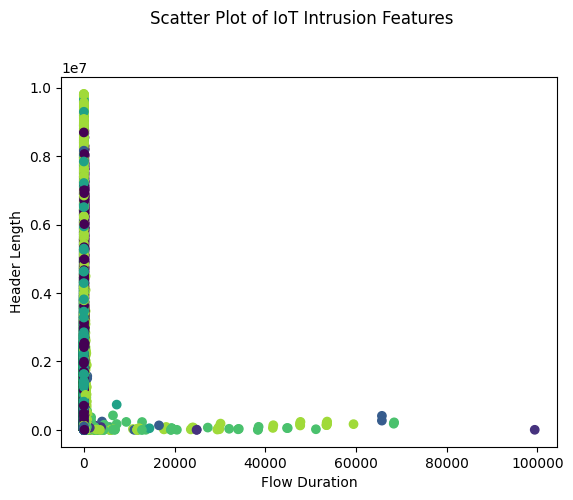

In [6]:
plt.scatter(x=iot_df['flow_duration'], y=iot_df['Header_Length'], c=iot_df['target'], cmap='viridis')
plt.xlabel('Flow Duration')
plt.ylabel('Header Length')
plt.suptitle("Scatter Plot of IoT Intrusion Features", y=1.02)
plt.show()

In [7]:
# Splitting data for modeling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [8]:
# Initialize and train the Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [9]:
# Predict on the test set
y_pred = clf.predict(X_test)



In [10]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Decision Tree model: {accuracy:.2f}")  # why we need "F" in the print statment



Accuracy of the Decision Tree model: 0.99


In [11]:
### how will you be able to print the confusion metrics and F1-Score?? you may need to look to last session
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))


Confusion Matrix:
[[  6646     17      0      1      0    268    335     19]
 [    14     47      0      0      0     19     17      3]
 [     4      0 229010     12      0     10      2      0]
 [     1      0     17  54496      0      0      1      0]
 [     0      0      0      1  17797      0      0      0]
 [   264      7     20      0      0   1956    145     26]
 [   298     13      2      0      0    148   2765     28]
 [    24      2      0      0      0     27     23     88]]
F1 Score: 0.9943753353419394


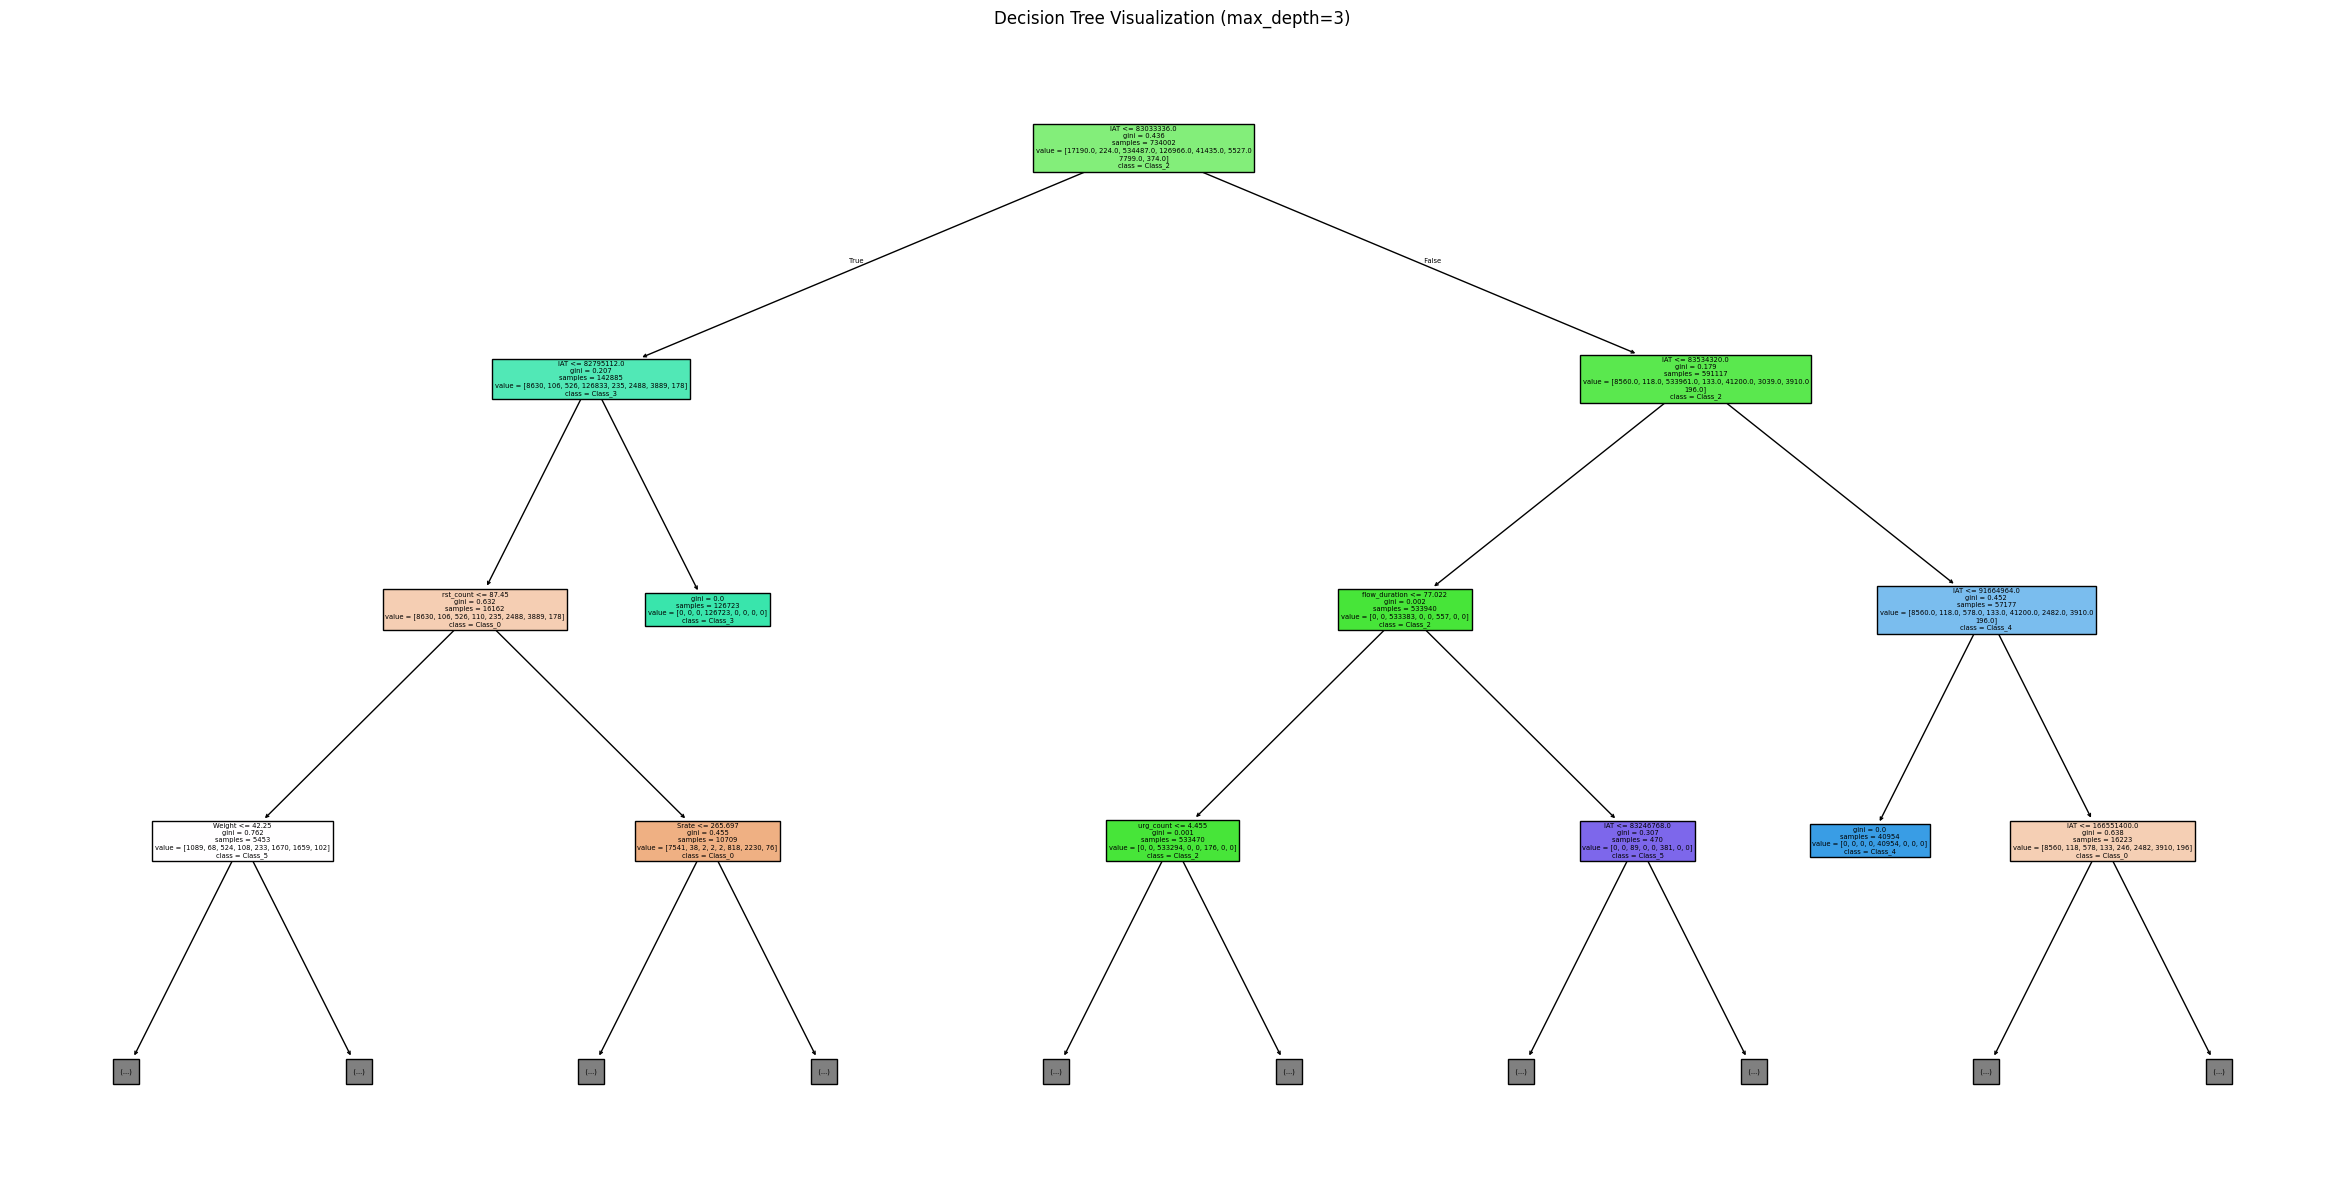

In [17]:
# Visualize the Decision Tree (limited depth for readability)
plt.figure(figsize=(30, 15))
plot_tree(clf,
          feature_names=X.columns,
          class_names=[f'Class_{i}' for i in range(len(clf.classes_))],
          filled=True,
          max_depth=3)  # Limit depth for visualization
plt.title('Decision Tree Visualization (max_depth=3)')
plt.show()


Top 10 Feature Importances:
               Importance
IAT              0.962100
flow_duration    0.005308
rst_count        0.004894
Weight           0.004163
Srate            0.003369
fin_count        0.003338
Header_Length    0.003156
Rate             0.001753
urg_count        0.001665
Min              0.001283


<Figure size 1000x600 with 0 Axes>

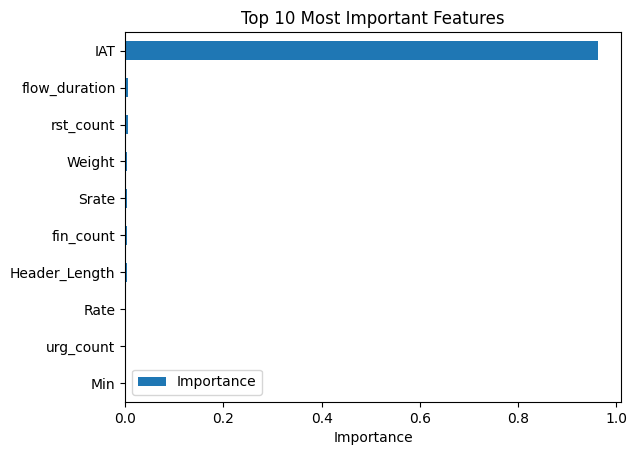

In [13]:
# Display feature importance
feature_importances = pd.DataFrame(
    clf.feature_importances_,
    index=X.columns,
    columns=['Importance']
).sort_values('Importance', ascending=False)

print('Top 10 Feature Importances:')
print(feature_importances.head(10))

# Plot top 10
plt.figure(figsize=(10, 6))
feature_importances.head(10).plot(kind='barh')
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features')
plt.gca().invert_yaxis()
plt.show()



***Task2***
Save the decision tree model and uploaded to GitHub as well.

